### Train deeper layers
To improve F1-sscore, we unfroze additional deeper layers in both VGG and EffNet  models for training:
one and two convolutional layers for the VGG16 model and batch normalization and convolutional layers for EffNetB4 model

To avoid overfitting when increasing the number of trainable parameters, we expanded the training dataset sevenfold by adding deterministic augmentations.

In the next cell  summary of layers in VGG16 model is checked

In [ ]:
from tensorflow.keras.applications import VGG16
x = VGG16(weights = 'imagenet',include_top=False)
x.summary()

Here we train more layers from the base model to see if this improves the performance or not

First we train convolutional layer (-2),  and another  convolutional layer (-3) and both from VGG16 model (-2,-3)

In [ ]:
 block5_conv1 (Conv2D)       (None, None, None, 512)   2359808   
                                                                 
 block5_conv2 (Conv2D)       (None, None, None, 512)   2359808   
                                                                 
 block5_conv3 (Conv2D)       (None, None, None, 512)   2359808   
                                                                 
 block5_pool (MaxPooling2D)  (None, None, None, 512)   0         
                                                                 
=================================================================
Total params: 14,714,688
Trainable params: 14,714,688
Non-trainable params: 0
___________________________

In the following cell I found the matched layers in model and in weights

In weights, the layers with no parameter are missing. dense layers also has weights + a bias vector

In [ ]:
## Model definition
#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x =VGG16(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = 'relu'
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)
    

    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]
    

## model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model
    

#######################################################################


model_name       = 'vgg_train_conv_relu'

pretrained_model = pretrained_model_func(input_shape, 3,'relu') ## REGRESSION: number of classes 1 instead of 3
weights =glob.glob('../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_2_layer_relu/'+val_dir+'*.hdf5')[0]
print(weights)

###############################################################################

loaded_1 = keras.models.load_model(
    weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
)

#print(len(pretrained_model.get_weights())) ## this is model
weights_list = loaded_1.get_weights()      ## This is weights

pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
pretrained_model.layers[-9].set_weights([weights_list[-12],weights_list[-11]])




pretrained_list  = pretrained_model.layers
print('num of layers',len(pretrained_list))
print('layer -1',pretrained_list[-1])
print('layer -1',pretrained_list[-1].get_weights()[0].shape)
print('layer -1',pretrained_list[-1].get_weights()[1].shape)
print('layer -2',pretrained_list[-2])
print('layer -2',pretrained_list[-2].get_weights())
print('layer -3',pretrained_list[-3])
print('layer -3',pretrained_list[-3].get_weights()[0].shape)
print('layer -3',pretrained_list[-3].get_weights()[1].shape)
print('layer -4',pretrained_list[-4])
print('layer -4',pretrained_list[-4].get_weights()[0].shape)
print('layer -4',pretrained_list[-4].get_weights()[1].shape)
print('layer -5',pretrained_list[-5])
print('layer -5',pretrained_list[-5].get_weights())
print('layer -6',pretrained_list[-6])
print('layer -6',pretrained_list[-6].get_weights())
print('layer -7',pretrained_list[-7])
print('layer -7',pretrained_list[-7].get_weights()[0].shape)
print('layer -7',pretrained_list[-7].get_weights()[1].shape)

print('layer -8',pretrained_list[-8])
print('layer -8',pretrained_list[-8].get_weights()[0].shape)
print('layer -8',pretrained_list[-8].get_weights()[1].shape)
print('layer -9',pretrained_list[-9])
print('layer -9',pretrained_list[-9].get_weights()[0].shape)
print('layer -9',pretrained_list[-9].get_weights()[1].shape)



print('newwwwwwwwwwwwwwWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWWeights')
print('num of layers',len(weights_list))
print('layer -1',weights_list[-1].shape)
print('layer -2',weights_list[-2].shape)
print('layer -3',weights_list[-3].shape)
print('layer -4',weights_list[-4].shape)
print('layer -5',weights_list[-5].shape)
print('layer -6',weights_list[-6].shape)
print('layer -7',weights_list[-7].shape)
print('layer -8',weights_list[-8].shape)
print('layer -9',weights_list[-9].shape)
print('layer -10',weights_list[-10].shape)
print('layer -11',weights_list[-11].shape)
print('layer -12',weights_list[-12].shape)
print('layer -13',weights_list[-13].shape)
print('layer -14',weights_list[-14].shape)
print('layer -15',weights_list[-15].shape)

print('enddddddddddddddddddddddddddddddddddddddddddd of one foldddddddddddddddddddddddddddddddddddd')


../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_2_layer_relu\1st_part_best_weights.05-1.52.hdf5
num of layers 24
layer -1 <keras.layers.core.dense.Dense object at 0x000001EF5FC62400>
layer -1 (128, 3)
layer -1 (3,)
layer -2 <keras.layers.core.dropout.Dropout object at 0x000001EF5FC2CD60>
layer -2 []
layer -3 <keras.layers.core.dense.Dense object at 0x000001EF5FCF1670>
layer -3 (128, 128)
layer -3 (128,)
layer -4 <keras.layers.core.dense.Dense object at 0x000001EF5FC2CFD0>
layer -4 (25088, 128)
layer -4 (128,)
layer -5 <keras.layers.core.flatten.Flatten object at 0x000001EF5FCF1F10>
layer -5 []
layer -6 <keras.layers.pooling.MaxPooling2D object at 0x000001EF5FC2C2E0>
layer -6 []
layer -7 <keras.layers.convolutional.Conv2D object at 0x000001EF5FC2C0D0>
layer -7 (3, 3, 512, 512)
layer -7 (512,)
layer -8 <keras.layers.convolutional.Conv2D object at 0x000001EF5FBFCFA0>
layer -8 (3, 3, 512, 512)
layer -8 (512,)
layer -9 <keras.layers.convolutional.Conv2D object

In [ ]:
 block5_conv1 (Conv2D)       (None, 14, 14, 512)       2359808   
                                                                 
 block5_conv2 (Conv2D)       (None, 14, 14, 512)       2359808   
                                                                 
 block5_conv3 (Conv2D)       (None, 14, 14, 512)       2359808   
                                                                 
 block5_pool (MaxPooling2D)  (None, 7, 7, 512)         0         
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 fc1 (Dense)                 (None, 128)               3211392   
                                                                 
 fc2 (Dense)                 (None, 128)               16512     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 predictions (Dense)         (None, 3)                 387       
                                                                 
=================================================================
Total params: 17,942,979
Trainable params: 3,228,291
Non-trainable params: 14,714,688

### Next cells VGG16 + layer (-2) as conv2D + relu

In [ ]:
VALIDATION_DIR = ['1st_part','2nd_part','3rd_part']
RESULTS        = '../../results/Train_more_layers/'
SAMPLES        = '../../results/Train_more_layers/initial_relu/s/main_img_'
LAYER_TYPE     = 'relu'
validation_LABEL_PATH = '../../data/folded_data/3fold_CV/All_samples_total_score_Median/'+val_dir+'_val_total_score/validation/validation_newlabels.txt'
MODEL_PATH     = '../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_2_layer_relu/'

In [ ]:
#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x = VGG16(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = 'relu'
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)



    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]



#Create your own model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model


#######################################################################

validation_slide = ['1st_part','2nd_part','3rd_part']
model_name       = 'vgg_train_conv_min2_relu'
### I took the best models in terms of TP 

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
for val_s in validation_slide:
    val_dir          = val_s # loop over all groups as validation dataset


    validation_DATA_PATH  = val_dir+'_validation/'
    validation_LABEL_PATH = validation_LABEL_PATH

    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_samples = np.zeros((n_v, input_shape[0], input_shape[1], 3), dtype=np.float32)
    validation_label = np.zeros((n_v,), int)

    # Reading true labels of validation set


    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
            
   
    for i in range(n_v):
        mod_img = validation_samples[i,:, :].astype(np.float32)
        validation_samples[i, :, :, :] = mod_img
    ##After we took all validation tiles we defined the model   

    pretrained_model = pretrained_model_func(input_shape, 3,'relu') ## REGRESSION: number of classes 1 instead of 3
    weights =glob.glob(MODEL_PATH+val_dir+'*.hdf5')[0]
    print(weights)

    ###############################################################################
    
    loaded_1 = keras.models.load_model(
        weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
    )

    print(len(pretrained_model.get_weights())) ## this is model
    weights_list = loaded_1.get_weights()      ## This is weights
    print(len(weights_list))
  
    ## Setting Weights      
    pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
    pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
    pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
    pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
    pretrained_model.layers[-9].set_weights([weights_list[-12],weights_list[-11]])
    
    
    
    
    ###############################################################################

    preds = pretrained_model.predict(validation_samples)    
    # Max predictions in numpy array
    y_pred = np.argmax(preds,axis=1)  # 0,1 or 2
    x_l = range(len(y_pred))

    ################################################################
    ### Here all predicted labels are saved in the following file
    with open(validation_LABEL_PATH,'r') as f: 
        with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','w') as fout: 
            for i,line in zip(y_pred,f):
                print(line.split(' ')[0 ],np.int(i),sep=' ',file=fout)
        fout.close()
    f.close()


    ### This is for extracting slide number from images to add
    keys = []
    Slide_dict = {}
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            S_num = str(line.split(' ')[0][6:8])
            if '.' in S_num:
                S_num = S_num.replace('.','')
            if '_' in S_num:
                S_num = S_num.replace('_','')
            if S_num not in keys:
                keys.append(S_num)
                Slide_dict[S_num]=[]

    fout.close()
    #########################################################
    ### Add all scores of tiles to the slide key
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=line.split(' ')[0][6:8]
            if '.' in key_temp:
                key_temp = key_temp.replace('.','')
            if '_' in key_temp:
                key_temp = key_temp.replace('_','')
           
            Slide_dict[key_temp].append(float(line.split(' ')[1].strip()))

    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_slide = np.ones(len(y_pred))  
    offset = 0
    for k in Slide_dict.keys():
        class_0 = [index for index, element in enumerate(Slide_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Slide_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Slide_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_slide[offset:offset+len(Slide_dict[k])]= majority_vote
        #print(y_pred_slide[offset:offset+len(Slide_dict[k])])
        offset += len(Slide_dict[k])
    ################################################################
    
    ### Add all scores of tiles to the Image name key
    keys = []
    Image_dict = {}
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            I_num = str(line.split('___')[0])
            if I_num not in keys:
                keys.append(I_num)
                Image_dict[I_num]=[]

    fout.close()
    
   
    with open(RESULTS+model_name+'_'+val_dir+'_validation_predicted_newlabels.txt','r') as fout: 
        for line in fout:
            key_temp=str(line.split('___')[0])
            Image_dict[key_temp].append(float(line.split(' ')[1].strip()))

    #print(Image_dict.keys())
    
    
    #### Change all tile scores to the score of majority of tiles 
    y_pred_image = np.ones(len(y_pred))  
    offset = 0
    for k in Image_dict.keys():
        class_0 = [index for index, element in enumerate(Image_dict[k]) if element == 0]
        class_1 = [index for index, element in enumerate(Image_dict[k]) if element == 1]
        class_2 = [index for index, element in enumerate(Image_dict[k]) if element == 2]
        majority_vote = np.argmax([len(class_0),len(class_1),len(class_2)]) 
        y_pred_image[offset:offset+len(Image_dict[k])]= majority_vote
        #print(y_pred_image[offset:offset+len(Image_dict[k])])
        offset += len(Image_dict[k])

    

    
    tile_based_scores[val_dir]  = pd.DataFrame(classification_report(precise_scores,y_pred,output_dict=True)).transpose()
    image_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_image,output_dict=True)).transpose()
    slide_based_scores[val_dir] = pd.DataFrame(classification_report(precise_scores,y_pred_slide,output_dict=True)).transpose()
    

df_tile  = pd.concat([tile_based_scores['1st_part'], tile_based_scores['2nd_part'],tile_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])
df_image = pd.concat([image_based_scores['1st_part'], image_based_scores['2nd_part'],image_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])
df_slide = pd.concat([slide_based_scores['1st_part'], slide_based_scores['2nd_part'],slide_based_scores['3rd_part']], axis=1,keys=['fold1','fold2','fold3'])


df_tile.to_csv('predict_result_3cv/'+model_name+'_tiles.csv')
df_image.to_csv('predict_result_3cv/'+model_name+'_image.csv')
df_slide.to_csv('predict_result_3cv/'+model_name+'_slide.csv')

### Results for VGG16 + layer (-2) as conv2D + relu

In [ ]:
model_name = 'vgg_train_conv_min2_relu'

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead tr th {
        text-align: left;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr>
      <th></th>
      <th colspan="3" halign="left">fold1</th>
      <th colspan="3" halign="left">fold2</th>
      <th colspan="3" halign="left">fold3</th>
      <th colspan="3" halign="left">Average</th>
    </tr>
    <tr>
      <th></th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Low</th>
      <td>0.661550</td>
      <td>0.788655</td>
      <td>0.719533</td>
      <td>0.490032</td>
      <td>1.000000</td>
      <td>0.657747</td>
      <td>1.000000</td>
      <td>0.389293</td>
      <td>0.560419</td>
      <td>0.717194</td>
      <td>0.725983</td>
      <td>0.721562</td>
    </tr>
    <tr>
      <th>Medium</th>
      <td>0.651057</td>
      <td>0.494266</td>
      <td>0.561930</td>
      <td>0.611830</td>
      <td>0.244280</td>
      <td>0.349156</td>
      <td>0.194444</td>
      <td>1.000000</td>
      <td>0.325581</td>
      <td>0.485777</td>
      <td>0.579515</td>
      <td>0.528522</td>
    </tr>
    <tr>
      <th>High</th>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>0.666667</td>
      <td>0.687500</td>
      <td>0.676923</td>
      <td>1.000000</td>
      <td>0.203704</td>
      <td>0.338462</td>
      <td>0.888889</td>
      <td>0.630401</td>
      <td>0.737656</td>
    </tr>
    <tr>
      <th>Micro_average</th>
      <td>0.693989</td>
      <td>0.693989</td>
      <td>0.693989</td>
      <td>0.557548</td>
      <td>0.557548</td>
      <td>0.557548</td>
      <td>0.408355</td>
      <td>0.408355</td>
      <td>0.408355</td>
      <td>0.553297</td>
      <td>0.553297</td>
      <td>0.553297</td>
    </tr>
    <tr>
      <th>weighted_average</th>
      <td>0.692986</td>
      <td>0.693989</td>
      <td>0.693487</td>
      <td>0.591766</td>
      <td>0.557548</td>
      <td>0.574147</td>
      <td>0.884958</td>
      <td>0.408355</td>
      <td>0.558839</td>
      <td>0.723236</td>
      <td>0.553297</td>
      <td>0.626955</td>
    </tr>
  </tbody>
</table>
</div>

### Results for  VGG16 + layer (-2)(conv) + leakyRelU

In [ ]:
model_name       = 'vgg_train_conv_min2_Leakyrelu'

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead tr th {
        text-align: left;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr>
      <th></th>
      <th colspan="3" halign="left">fold1</th>
      <th colspan="3" halign="left">fold2</th>
      <th colspan="3" halign="left">fold3</th>
      <th colspan="3" halign="left">Average</th>
    </tr>
    <tr>
      <th></th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Low</th>
      <td>0.661550</td>
      <td>0.788655</td>
      <td>0.719533</td>
      <td>0.490032</td>
      <td>1.000000</td>
      <td>0.657747</td>
      <td>1.000000</td>
      <td>0.541970</td>
      <td>0.702958</td>
      <td>0.717194</td>
      <td>0.776875</td>
      <td>0.745843</td>
    </tr>
    <tr>
      <th>Medium</th>
      <td>0.651057</td>
      <td>0.494266</td>
      <td>0.561930</td>
      <td>1.000000</td>
      <td>0.073801</td>
      <td>0.137457</td>
      <td>0.241379</td>
      <td>1.000000</td>
      <td>0.388889</td>
      <td>0.630812</td>
      <td>0.522689</td>
      <td>0.571683</td>
    </tr>
    <tr>
      <th>High</th>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>0.592593</td>
      <td>1.000000</td>
      <td>0.744186</td>
      <td>1.000000</td>
      <td>0.388889</td>
      <td>0.560000</td>
      <td>0.864198</td>
      <td>0.796296</td>
      <td>0.828859</td>
    </tr>
    <tr>
      <th>Micro_average</th>
      <td>0.693989</td>
      <td>0.693989</td>
      <td>0.693989</td>
      <td>0.550018</td>
      <td>0.550018</td>
      <td>0.550018</td>
      <td>0.551166</td>
      <td>0.551166</td>
      <td>0.551166</td>
      <td>0.598391</td>
      <td>0.598391</td>
      <td>0.598391</td>
    </tr>
    <tr>
      <th>weighted_average</th>
      <td>0.692986</td>
      <td>0.693989</td>
      <td>0.693487</td>
      <td>0.762505</td>
      <td>0.550018</td>
      <td>0.639062</td>
      <td>0.891661</td>
      <td>0.551166</td>
      <td>0.681236</td>
      <td>0.782384</td>
      <td>0.598391</td>
      <td>0.678129</td>
    </tr>
  </tbody>
</table>
</div>

### Next cells VGG16 + layer (-2,3)conv  + relu

In [ ]:
MODEL_PATH = '../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_3_layer_relu/'

In [ ]:
#################################################################################################################################
def pretrained_model_func(img_shape, num_classes,layer_type):
    inputs = tf.keras.Input(shape=(224,224,3))

    x = VGG16(
      input_tensor=inputs, 
      include_top=False,
      weights='imagenet' )

    x.trainable = False

    layer_type = 'relu'
    x = tf.keras.layers.Flatten(name='flatten')(x.output)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc1')(x)
    x = tf.keras.layers.Dense(128, activation=layer_type, name='fc2')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)
    x = tf.keras.layers.Dense(3, activation='softmax', name='predictions')(x)



    METRICS = [
    keras.metrics.SparseCategoricalAccuracy(),
    MulticlassTruePositives()]


#Create your own model 
    pretrained_model = tf.keras.Model(inputs, x)
    pretrained_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=METRICS)
    return pretrained_model



model_name       = 'vgg_train_conv_min2_min3_relu'
### I took the best models in terms of TP 

tile_based_scores = {}
image_based_scores = {}
slide_based_scores = {}
for val_s in validation_slide:
    val_dir          = val_s # loop over all groups as validation dataset
    
    validation_DATA_PATH  = val_dir+'_validation/'
   

    ### Max and min of Median column 
    max_score = max(df_scores['Median'])
    min_score = min(df_scores['Median'])

    ##Normalized thresholds
    low = (10-(min_score))/(max_score-min_score)
    mid = (25-(min_score))/(max_score-min_score)
    
    ## Initialize validation samples
    input_shape = (224,224,3)
    validation_images = glob.glob(validation_DATA_PATH+'*.tif')
    n_v= len(validation_images) 
    validation_samples = np.zeros((n_v, input_shape[0], input_shape[1], 3), dtype=np.float32)
    validation_label = np.zeros((n_v,), int)

    # Reading true labels of validation set


    precise_scores = []
    image_names = []
    with open(validation_LABEL_PATH,'r') as f:
        for ctr,line in zip(range(n_v),f):
            validation_samples[ctr,:,:,:] = cv2.imread(validation_DATA_PATH+(line.split()[0]))
            la = float(line.split()[1])
            
            if la > mid:
                validation_label[ctr] = 2
            elif la > low:
                validation_label[ctr] = 1
            else:
                validation_label[ctr] = 0
            precise_scores.append(validation_label[ctr])
            image_names.append(line.split(' ')[0 ])  
            
   
    for i in range(n_v):
        mod_img = validation_samples[i,:, :].astype(np.float32)
        validation_samples[i, :, :, :] = mod_img
    ##After we took all validation tiles we defined the model   

    pretrained_model = pretrained_model_func(input_shape, 3,'relu') ## REGRESSION: number of classes 1 instead of 3
    weights =glob.glob(MODEL_PATH+val_dir+'*.hdf5')[0]
    print(weights)
    
    ###############################################################################
    loaded_1 = keras.models.load_model(
        weights, custom_objects={"MulticlassTruePositives": MulticlassTruePositives,'Functional':EfficientNetB4()}
    )

    print(len(pretrained_model.get_weights())) ## this is model
    weights_list = loaded_1.get_weights()      ## This is weights
    print(len(weights_list))
)
    ## Setting weights        
    pretrained_model.layers[-1].set_weights([weights_list[-2],weights_list[-1]])
    pretrained_model.layers[-3].set_weights([weights_list[-4],weights_list[-3]])
    pretrained_model.layers[-4].set_weights([weights_list[-6],weights_list[-5]])
    pretrained_model.layers[-7].set_weights([weights_list[-8],weights_list[-7]])
    pretrained_model.layers[-8].set_weights([weights_list[-10],weights_list[-9]])
    pretrained_model.layers[-9].set_weights([weights_list[-12],weights_list[-11]])
    
    
    ###############################################################################
    # Make predictions on validation samples
    #with tf.device('/CPU:0'):
    preds = pretrained_model.predict(validation_samples)
    
    # Max predictions in numpy array
    y_pred = np.argmax(preds,axis=1)  # 0,1 or 2
    x_l = range(len(y_pred))


### Results for  VGG16 + layer (-2,3)conv  + relu

In [ ]:
model_name       = 'vgg_train_conv_min2_min3_relu'

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead tr th {
        text-align: left;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr>
      <th></th>
      <th colspan="3" halign="left">fold1</th>
      <th colspan="3" halign="left">fold2</th>
      <th colspan="3" halign="left">fold3</th>
      <th colspan="3" halign="left">Average</th>
    </tr>
    <tr>
      <th></th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Low</th>
      <td>0.661550</td>
      <td>0.788655</td>
      <td>0.719533</td>
      <td>0.273216</td>
      <td>1.000000</td>
      <td>0.429175</td>
      <td>0.692449</td>
      <td>1.000000</td>
      <td>0.818280</td>
      <td>0.542405</td>
      <td>0.929552</td>
      <td>0.685066</td>
    </tr>
    <tr>
      <th>Medium</th>
      <td>0.651057</td>
      <td>0.494266</td>
      <td>0.561930</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>NaN</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>NaN</td>
      <td>0.217019</td>
      <td>0.164755</td>
      <td>0.187310</td>
    </tr>
    <tr>
      <th>High</th>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>NaN</td>
      <td>1.000000</td>
      <td>0.796296</td>
      <td>0.886598</td>
      <td>0.666667</td>
      <td>0.598765</td>
      <td>0.630894</td>
    </tr>
    <tr>
      <th>Micro_average</th>
      <td>0.693989</td>
      <td>0.693989</td>
      <td>0.693989</td>
      <td>0.273216</td>
      <td>0.273216</td>
      <td>0.273216</td>
      <td>0.782383</td>
      <td>0.782383</td>
      <td>0.782383</td>
      <td>0.583196</td>
      <td>0.583196</td>
      <td>0.583196</td>
    </tr>
    <tr>
      <th>weighted_average</th>
      <td>0.692986</td>
      <td>0.693989</td>
      <td>0.693487</td>
      <td>0.074647</td>
      <td>0.273216</td>
      <td>0.117258</td>
      <td>0.706501</td>
      <td>0.782383</td>
      <td>0.742508</td>
      <td>0.491378</td>
      <td>0.583196</td>
      <td>0.533364</td>
    </tr>
  </tbody>
</table>
</div>

### Results for VGG16 + layer (-2,-3) conv + LeakyReLU

In [ ]:
MODEL_PATH = '../new_runs/Corrected_results_accuracy/train_more_layers/vgg_aug_3fold_blurred_3_layer_LeakyReLU/'

In [ ]:
model_name       = 'vgg_train_conv_min2_min3_Leakyrelu'

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead tr th {
        text-align: left;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr>
      <th></th>
      <th colspan="3" halign="left">fold1</th>
      <th colspan="3" halign="left">fold2</th>
      <th colspan="3" halign="left">fold3</th>
      <th colspan="3" halign="left">Average</th>
    </tr>
    <tr>
      <th></th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Low</th>
      <td>0.668911</td>
      <td>1.000000</td>
      <td>0.801613</td>
      <td>0.490032</td>
      <td>1.000000</td>
      <td>0.657747</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>NaN</td>
      <td>0.386314</td>
      <td>0.666667</td>
      <td>0.489169</td>
    </tr>
    <tr>
      <th>Medium</th>
      <td>1.000000</td>
      <td>0.379587</td>
      <td>0.550291</td>
      <td>1.000000</td>
      <td>0.073801</td>
      <td>0.137457</td>
      <td>0.142811</td>
      <td>1.000000</td>
      <td>0.249929</td>
      <td>0.714270</td>
      <td>0.484463</td>
      <td>0.577338</td>
    </tr>
    <tr>
      <th>High</th>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>0.592593</td>
      <td>1.000000</td>
      <td>0.744186</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>NaN</td>
      <td>0.530864</td>
      <td>0.666667</td>
      <td>0.591065</td>
    </tr>
    <tr>
      <th>Micro_average</th>
      <td>0.753643</td>
      <td>0.753643</td>
      <td>0.753643</td>
      <td>0.550018</td>
      <td>0.550018</td>
      <td>0.550018</td>
      <td>0.142811</td>
      <td>0.142811</td>
      <td>0.142811</td>
      <td>0.482157</td>
      <td>0.482157</td>
      <td>0.482157</td>
    </tr>
    <tr>
      <th>weighted_average</th>
      <td>0.835209</td>
      <td>0.753643</td>
      <td>0.792332</td>
      <td>0.762505</td>
      <td>0.550018</td>
      <td>0.639062</td>
      <td>0.020395</td>
      <td>0.142811</td>
      <td>0.035693</td>
      <td>0.539370</td>
      <td>0.482157</td>
      <td>0.509161</td>
    </tr>
  </tbody>
</table>
</div>

3
3


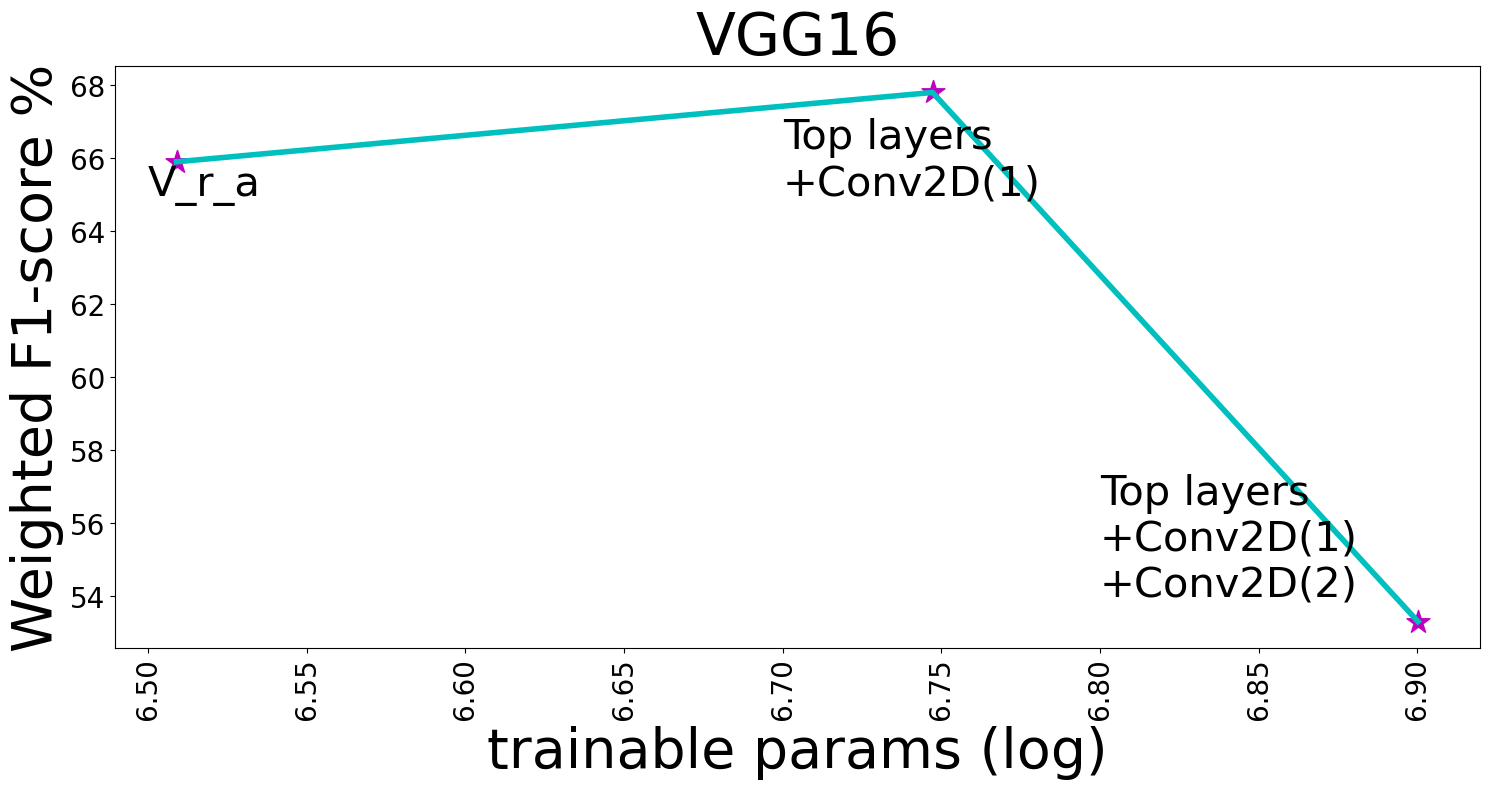

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
parameters  = np.array([3228291,5588099,7947907])
Weighted_F1_score = np.array([65.9,67.8,53.3])
from scipy import interpolate


plt.figure(figsize=(15,8))

print(len(parameters))
print(len(Weighted_F1_score))
plt.scatter(np.log10(parameters),Weighted_F1_score,marker='*',color='m',s=300)

plt.xlabel('trainable params (log)',fontsize=40)
plt.ylabel('Weighted F1-score %',fontsize=40)
plt.xticks(rotation=90,fontsize=20)
plt.yticks(fontsize=20)
#plt.xscale('log')

from scipy.signal import savgol_filter
yhat = savgol_filter(Weighted_F1_score, 3,2) 
plt.plot(np.log10(parameters),yhat,'c',linewidth=4)
plt.text(6.5, 65, "V_r_a", fontsize=30, color='black')
plt.text(6.70, 65, "Top layers\n+Conv2D(1)", fontsize=30, color='black')
plt.text(6.80, 54, "Top layers\n+Conv2D(1)\n+Conv2D(2)", fontsize=30, color='black')
plt.title('VGG16',fontsize=42)
plt.tight_layout()
plt.savefig('VGG_train_more_layers.png')